# Multiclass Classification for a balanced dataset

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from sklearn.datasets import make_classification

In [10]:
X,y = make_classification(n_samples = 10000, n_features = 10, n_classes=3, n_clusters_per_class=1)

In [13]:
y

array([1, 1, 2, ..., 1, 0, 2], shape=(10000,))

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression

In [18]:
logregmulti = LogisticRegression(n_jobs=-1)
logregmulti.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred = logregmulti.predict(X_test)

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [24]:
score=accuracy_score(y_pred,y_test)
print(score)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

0.8373333333333334
              precision    recall  f1-score   support

           0       0.78      0.77      0.77      1032
           1       0.90      0.91      0.91       993
           2       0.83      0.84      0.84       975

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000

[[793  93 146]
 [ 75 902  16]
 [155   3 817]]


# Binary classification for Unbalanced Dataset

In [40]:
from collections import Counter

In [31]:
X,y = make_classification(n_samples = 10000, n_features = 2, n_redundant=0, n_classes=2, n_clusters_per_class=1, weights=[0.99])

In [34]:
X.shape

(10000, 2)

In [41]:
Counter(y)

Counter({np.int64(0): 9851, np.int64(1): 149})

<Axes: xlabel='0', ylabel='1'>

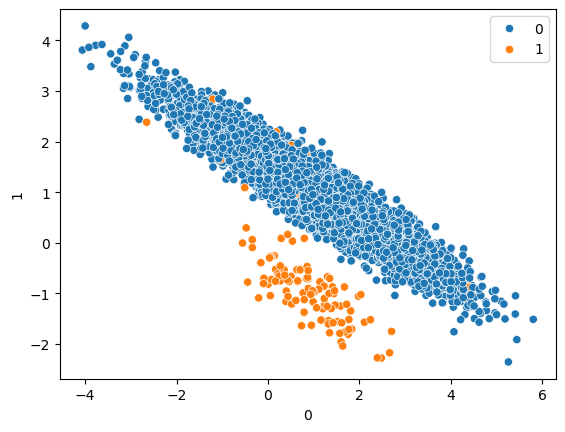

In [44]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
class_weight = [{0:w , 1:x} for w in [1 ,10, 25, 50, 100] for x in [1 ,10, 25, 50, 100]]

In [59]:
unbmodel = LogisticRegression()
c_values = [0.01, 0.1, 1, 10, 100]
params = [
    {'penalty': ['l1', 'l2'], 'solver': ['liblinear'], 'C': c_values, 'class_weight': class_weight},
    {'penalty': ['l2'], 'solver': ['sag', 'newton-cg', 'lbfgs'], 'C': c_values, 'class_weight': class_weight},
    {'penalty': ['l1', 'l2', 'elasticnet'], 'solver': ['saga'], 'C': c_values, 'l1_ratio': [0.5], 'class_weight': class_weight}  # only used when penalty='elasticnet'
]

params

[{'penalty': ['l1', 'l2'],
  'solver': ['liblinear'],
  'C': [0.01, 0.1, 1, 10, 100],
  'class_weight': [{0: 1, 1: 1},
   {0: 1, 1: 10},
   {0: 1, 1: 25},
   {0: 1, 1: 50},
   {0: 1, 1: 100},
   {0: 10, 1: 1},
   {0: 10, 1: 10},
   {0: 10, 1: 25},
   {0: 10, 1: 50},
   {0: 10, 1: 100},
   {0: 25, 1: 1},
   {0: 25, 1: 10},
   {0: 25, 1: 25},
   {0: 25, 1: 50},
   {0: 25, 1: 100},
   {0: 50, 1: 1},
   {0: 50, 1: 10},
   {0: 50, 1: 25},
   {0: 50, 1: 50},
   {0: 50, 1: 100},
   {0: 100, 1: 1},
   {0: 100, 1: 10},
   {0: 100, 1: 25},
   {0: 100, 1: 50},
   {0: 100, 1: 100}]},
 {'penalty': ['l2'],
  'solver': ['sag', 'newton-cg', 'lbfgs'],
  'C': [0.01, 0.1, 1, 10, 100],
  'class_weight': [{0: 1, 1: 1},
   {0: 1, 1: 10},
   {0: 1, 1: 25},
   {0: 1, 1: 50},
   {0: 1, 1: 100},
   {0: 10, 1: 1},
   {0: 10, 1: 10},
   {0: 10, 1: 25},
   {0: 10, 1: 50},
   {0: 10, 1: 100},
   {0: 25, 1: 1},
   {0: 25, 1: 10},
   {0: 25, 1: 25},
   {0: 25, 1: 50},
   {0: 25, 1: 100},
   {0: 50, 1: 1},
   {0: 50, 

In [60]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()

In [63]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=unbmodel, param_grid=params, cv = cv, scoring='accuracy')

In [64]:
grid

,estimator,LogisticRegression()
,param_grid,"[{'C': [0.01, 0.1, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, {'C': [0.01, 0.1, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l2'], 'solver': ['sag', 'newton-cg', ...]}, ...]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [66]:
grid.fit(X_train, y_train)

c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: T

,estimator,LogisticRegression()
,param_grid,"[{'C': [0.01, 0.1, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, {'C': [0.01, 0.1, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l2'], 'solver': ['sag', 'newton-cg', ...]}, ...]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [67]:
grid.best_params_

{'C': 0.1,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [68]:
grid.best_score_

np.float64(0.9944285714285714)

In [69]:
y_pred = grid.predict(X_test)

In [70]:
score=accuracy_score(y_pred,y_test)
print(score)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

0.9963333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2969
           1       0.74      1.00      0.85        31

    accuracy                           1.00      3000
   macro avg       0.87      1.00      0.92      3000
weighted avg       1.00      1.00      1.00      3000

[[2958   11]
 [   0   31]]
